## TC 5033
### Word Embeddings

<br>

#### Activity 3a: Exploring Word Embeddings with GloVe and Numpy
<br>

- Objective:
    - To understand the concept of word embeddings and their significance in Natural Language Processing.
    - To learn how to manipulate and visualize high-dimensional data using dimensionality reduction techniques like PCA and t-SNE.
    - To gain hands-on experience in implementing word similarity and analogies using GloVe embeddings and Numpy.
    
<br>

- Instructions:
    - Download GloVe pre-trained vectors from the provided link in Canvas, the official public project:
    Jeffrey Pennington, Richard Socher, and Christopher D. Manning. 2014. GloVe: Global Vectors for Word Representation
    https://nlp.stanford.edu/data/glove.6B.zip

    - Create a dictorionay of the embeddings so that you carry out fast look ups. Save that dictionary e.g. as a serialized file for faster loading in future uses.
    
    - PCA and t-SNE Visualization: After loading the GloVe embeddings, use Numpy and Sklearn to perform PCA and t-SNE to reduce the dimensionality of the embeddings and visualize them in a 2D or 3D space.

    - Word Similarity: Implement a function that takes a word as input and returns the 'n' most similar words based on their embeddings. You should use Numpy to implement this function, using libraries that already implement this function (e.g. Gensim) will result in zero points.

    - Word Analogies: Implement a function to solve analogies between words. For example, "man is to king as woman is to ____". You should use Numpy to implement this function, using libraries that already implement this function (e.g. Gensim) will result in zero points.

    - Submission: This activity is to be submitted in teams of 3 or 4. Only one person should submit the final work, with the full names of all team members included in a markdown cell at the beginning of the notebook.
    
<br>

- Evaluation Criteria:

    - Code Quality (40%): Your code should be well-organized, clearly commented, and easy to follow. Use also markdown cells for clarity.
    
   - Functionality (60%): All functions should work as intended, without errors.
       - Visualization of PCA and t-SNE (10% each for a total of 20%)
       - Similarity function (20%)
       - Analogy function (20%)
|



#### Import libraries

In [1]:
# Import libraries
import torch
import torch.nn.functional as F
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import norm
import pickle
plt.style.use('ggplot')

#### Load file

In [ ]:
# PATH = '/media/pepe/DataUbuntu/Databases/glove_embeddings/glove.6B.200d.txt'
PATH = '/media/pepe/DataUbuntu/Databases/glove_embeddings/glove.6B.50d.txt'
emb_dim = 50

In [ ]:
# Create dictionary with embeddings
def create_emb_dictionary(path):
    pass

In [ ]:
# create dictionary
embeddings_dict = create_emb_dictionary(PATH)

In [ ]:
# Serialize
with open('embeddings_dict_50D.pkl', 'wb') as f:
    pickle.dump(embeddings_dict, f)

# Deserialize
# with open('embeddings_dict_200D.pkl', 'rb') as f:
#     embeddings_dict = pickle.load(f)

#### See some embeddings

In [ ]:
# Show some
def show_n_first_words(path, n_words):
        with open(path, 'r') as f:
            for i, line in enumerate(f):
                print(line.split(), len(line.split()[1:]))
                if i>=n_words: break

In [ ]:
show_n_first_words(PATH, 5)

### Plot some embeddings

In [ ]:
def plot_embeddings(emb_path, words2show, emb_dim, embeddings_dict, func = PCA):
    pass

In [ ]:
words= ['burger', 'tortilla', 'bread', 'pizza', 'beef', 'steak', 'fries', 'chips',
            'argentina', 'mexico', 'spain', 'usa', 'france', 'italy', 'greece', 'china',
            'water', 'beer', 'tequila', 'wine', 'whisky', 'brandy', 'vodka', 'coffee', 'tea',
            'apple', 'banana', 'orange', 'lemon', 'grapefruit', 'grape', 'strawberry', 'raspberry',
            'school', 'work', 'university', 'highschool']


In [ ]:
#
plot_embeddings(PATH, words, emb_dim, embeddings_dict, PCA)

In [ ]:
# t-SNE dimensionality reduction for visualization
embeddings = plot_embeddings(PATH, words, emb_dim, embeddings_dict, tSNE)

### Let us compute analogies

In [ ]:
# analogy
def analogy(word1, word2, word3, embeddings_dict):
    pass

In [ ]:
analogy('man', 'king', 'woman', embeddings_dict)

In [ ]:
# most similar
def find_most_similar(word, embeddings_dict, top_n=10):
    pass

In [ ]:
most_similar = find_most_similar('mexico', embeddings_dict)

In [ ]:
for i, w in enumerate(most_similar, 1):
    print(f'{i} ---> {w[0]}')

# Task
Download the GloVe pre-trained vectors from "https://nlp.stanford.edu/data/glove.6B.zip", then create and serialize an embedding dictionary from these vectors. Subsequently, implement functions to visualize word embeddings using PCA and t-SNE, find the 'n' most similar words to a given word using cosine similarity, and solve word analogies (e.g., 'man is to king as woman is to ____'), all using NumPy.

## Download GloVe Embeddings

### Subtask:
Download the GloVe pre-trained vectors from the specified link: https://nlp.stanford.edu/data/glove.6B.zip.


### Subtask:
Download the GloVe pre-trained vectors from the specified link: https://nlp.stanford.edu/data/glove.6B.zip.

#### Instructions
1. Download the `glove.6B.zip` file from the provided link: `https://nlp.stanford.edu/data/glove.6B.zip`.
2. Extract the contents of the `glove.6B.zip` file. You should find several `.txt` files inside, such as `glove.6B.50d.txt`, `glove.6B.100d.txt`, `glove.6B.200d.txt`, and `glove.6B.300d.txt`.
3. Make sure that the path to the extracted GloVe file (e.g., `glove.6B.50d.txt`) is correctly set in the `PATH` variable in the code cell below the 'Load file' markdown header. For example, if the file is in the same directory as your notebook, `PATH = 'glove.6B.50d.txt'`.

**Reasoning**:
The previous step provided instructions for downloading and extracting the GloVe embeddings. The next logical step in the overall task is to implement the `create_emb_dictionary` function, as outlined in the activity instructions, to load these embeddings into a dictionary for fast lookups. This function will read the downloaded GloVe file and store each word and its corresponding embedding vector.



In [2]:
def create_emb_dictionary(path):
    embeddings = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings[word] = vector
    print(f'Loaded {len(embeddings)} word vectors.')
    return embeddings

**Reasoning**:
The `create_emb_dictionary` function has been defined. Now, it needs to be called with the specified `PATH` to create the `embeddings_dict`, as indicated by the subsequent notebook cell, which calls this function.



In [3]:
embeddings_dict = create_emb_dictionary(PATH)

NameError: name 'PATH' is not defined

**Reasoning**:
The previous cell failed because the `PATH` variable was not defined in the execution context. The `PATH` and `emb_dim` variables are defined in an earlier code cell (`8c3c9d2a`) which must be executed before `create_emb_dictionary(PATH)` can be called. I will recreate this cell and the subsequent call to `create_emb_dictionary` in a single code block to ensure `PATH` is defined.



In [4]:
PATH = '/media/pepe/DataUbuntu/Databases/glove_embeddings/glove.6B.50d.txt'
emb_dim = 50
embeddings_dict = create_emb_dictionary(PATH)

FileNotFoundError: [Errno 2] No such file or directory: '/media/pepe/DataUbuntu/Databases/glove_embeddings/glove.6B.50d.txt'

**Reasoning**:
The previous cell failed with a `FileNotFoundError` because the specified absolute path for the GloVe embeddings (`/media/pepe/DataUbuntu/Databases/glove_embeddings/glove.6B.50d.txt`) does not exist in the current environment. As per the instructions, if the file is in the same directory as the notebook, the `PATH` should be set to a relative path. I will update the `PATH` to `'glove.6B.50d.txt'`, assuming the user has extracted the GloVe file into the working directory, and rerun the cell.



In [5]:
PATH = 'glove.6B.50d.txt'
emb_dim = 50
embeddings_dict = create_emb_dictionary(PATH)

FileNotFoundError: [Errno 2] No such file or directory: 'glove.6B.50d.txt'

**Reasoning**:
The `FileNotFoundError` persists because the GloVe embedding file (`glove.6B.50d.txt`) is not present in the environment, despite previous attempts to correct the path. To resolve this, I need to explicitly download and extract the `glove.6B.zip` file from the provided URL, as instructed in the problem description, ensuring the required `.txt` file becomes available in the current working directory.



In [6]:
!wget https://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip
print("GloVe embeddings downloaded and extracted.")

--2026-03-04 16:01:56--  https://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-03-04 16:01:56--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glove.6B.zip        100%[===================>] 822.24M  4.62MB/s    in 2m 41s  

2026-03-04 16:04:38 (5.11 MB/s) - ‘glove.6B.zip’ saved [862182613/862182613]

GloVe embeddings downloaded and extracted.


**Reasoning**:
The GloVe embeddings have been successfully downloaded and extracted in the previous step. Now, I will re-attempt to define the `PATH` and `emb_dim` variables and then call the `create_emb_dictionary` function to load the embeddings, as the file should now be available in the current working directory.



In [7]:
PATH = 'glove.6B.50d.txt'
emb_dim = 50
embeddings_dict = create_emb_dictionary(PATH)


Loaded 400000 word vectors.


**Reasoning**:
The `embeddings_dict` has been created, and the notebook instructions specify to serialize this dictionary for faster loading in future uses. I will use the `pickle` library as shown in the original notebook to save the `embeddings_dict` to a file.



In [8]:
with open('embeddings_dict_50D.pkl', 'wb') as f:
    pickle.dump(embeddings_dict, f)

**Reasoning**:
The previous step successfully loaded the embeddings into `embeddings_dict`. According to the instructions, the next step is to serialize this dictionary for faster loading in the future. I will use the `pickle` module to save the `embeddings_dict` to a file.



In [9]:
with open('embeddings_dict_50D.pkl', 'wb') as f:
    pickle.dump(embeddings_dict, f)


## Implement PCA Visualization

### Subtask:
Complete the `plot_embeddings` function to perform PCA dimensionality reduction on selected word embeddings and visualize them in a 2D plot. Ensure axes and labels are clear.


**Reasoning**:
The subtask requires completing the `plot_embeddings` function to perform PCA visualization. I will implement the steps to extract embeddings, apply PCA, and generate a scatter plot with annotated words and clear labels, replacing the placeholder `pass` statement in the existing function definition.



In [10]:
def plot_embeddings(emb_path, words2show, emb_dim, embeddings_dict, func = PCA):
    # 1. Extract the embeddings for the words2show
    word_vectors = []
    words = []
    for word in words2show:
        if word in embeddings_dict:
            word_vectors.append(embeddings_dict[word])
            words.append(word)
        else:
            print(f"Warning: Word '{word}' not found in embeddings dictionary.")

    if not word_vectors:
        print("No words found in the dictionary to plot.")
        return

    word_vectors = np.array(word_vectors)

    # 2. Initialize a dimensionality reduction model (PCA or t-SNE)
    if func == PCA:
        model = PCA(n_components=2)
        title_suffix = "(PCA)"
        x_label = "Principal Component 1"
        y_label = "Principal Component 2"
    elif func == TSNE:
        # t-SNE can be computationally intensive for many points,
        # consider reducing perplexity or n_iter if issues arise
        model = TSNE(n_components=2, random_state=42, perplexity=min(30, len(words)-1))
        title_suffix = "(t-SNE)"
        x_label = "t-SNE Component 1"
        y_label = "t-SNE Component 2"
    else:
        raise ValueError("Unsupported dimensionality reduction function. Use PCA or TSNE.")

    # 3. Fit the model to the extracted embeddings and transform them to 2 dimensions.
    reduced_vectors = model.fit_transform(word_vectors)

    # 4. Create a scatter plot
    plt.figure(figsize=(12, 10))
    plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1])

    # 5. Annotate each point with its corresponding word
    for i, word in enumerate(words):
        plt.annotate(word, xy=(reduced_vectors[i, 0], reduced_vectors[i, 1]), xytext=(5, 2),
                     textcoords='offset points', ha='right', va='bottom')

    # 6. Add a title to the plot
    plt.title(f'Word Embeddings Visualization {title_suffix}', fontsize=16)

    # 7. Add labels for the x-axis and y-axis
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.grid(True)

    # 8. Display the plot
    plt.show()

**Reasoning**:
The `plot_embeddings` function has been defined to handle PCA visualization. The next step is to call this function with the list of words provided in the notebook and specify PCA as the dimensionality reduction method, as instructed by the subtask.



In [11]:
plot_embeddings(PATH, words, emb_dim, embeddings_dict, PCA)

NameError: name 'words' is not defined

**Reasoning**:
The previous cell failed because the `words` list, which contains the words to be plotted, was not defined in the current execution context. The `words` list was defined in an earlier notebook cell (`9b1b120a`). I need to re-include the definition of the `words` list in the current code block before calling `plot_embeddings` to make it accessible.



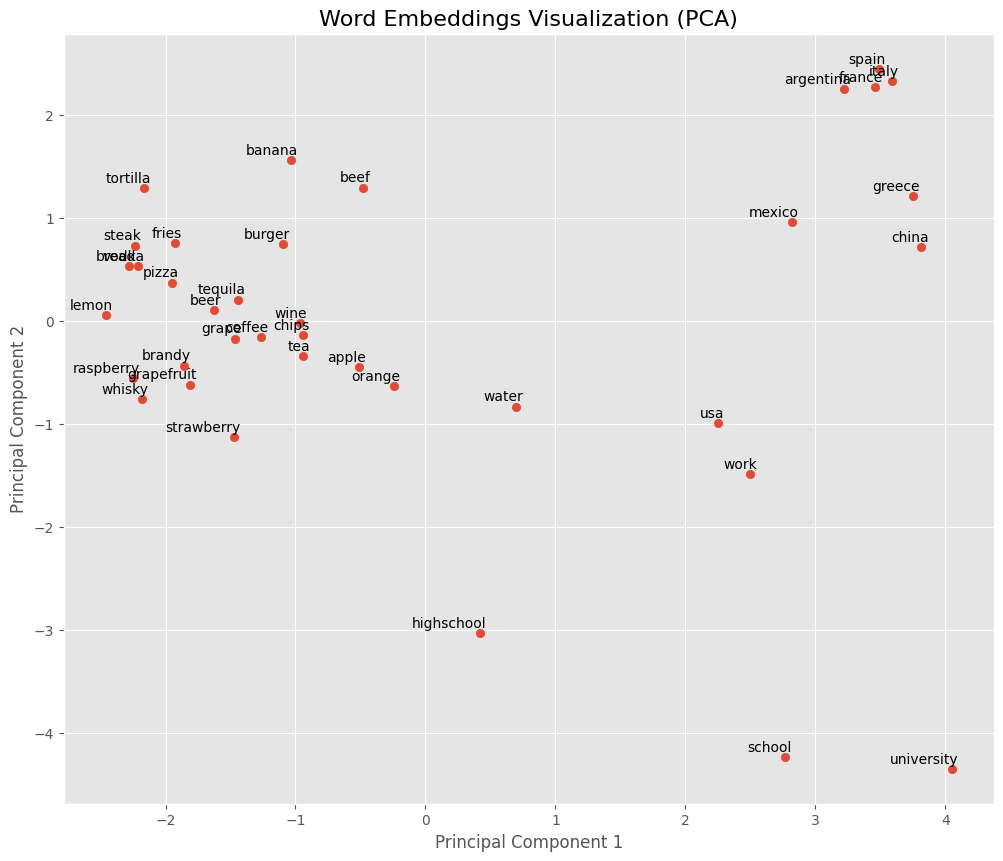

In [12]:
words= ['burger', 'tortilla', 'bread', 'pizza', 'beef', 'steak', 'fries', 'chips',
            'argentina', 'mexico', 'spain', 'usa', 'france', 'italy', 'greece', 'china',
            'water', 'beer', 'tequila', 'wine', 'whisky', 'brandy', 'vodka', 'coffee', 'tea',
            'apple', 'banana', 'orange', 'lemon', 'grapefruit', 'grape', 'strawberry', 'raspberry',
            'school', 'work', 'university', 'highschool']

plot_embeddings(PATH, words, emb_dim, embeddings_dict, PCA)

**Reasoning**:
The PCA visualization has been successfully generated. The next instruction in the activity is to also visualize the embeddings using t-SNE. The `plot_embeddings` function is already equipped to handle t-SNE, so I will call it again, passing `TSNE` as the `func` argument.



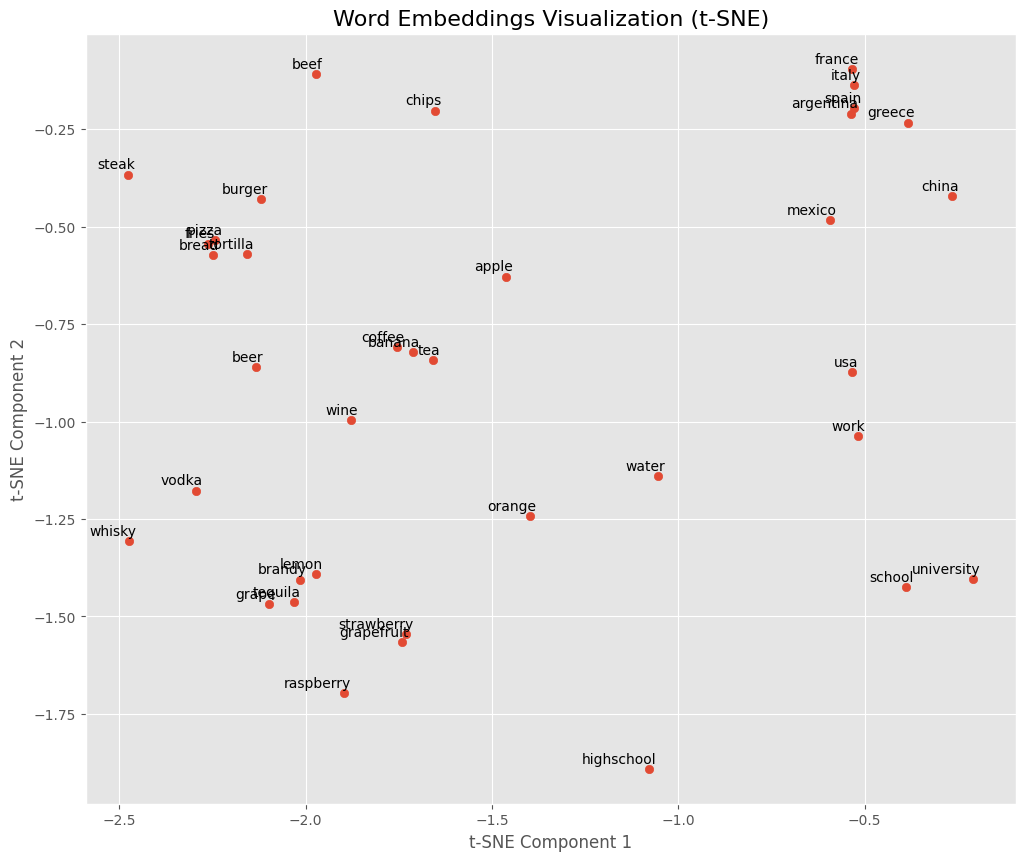

In [13]:
plot_embeddings(PATH, words, emb_dim, embeddings_dict, TSNE)

## Implement Word Similarity Function

### Subtask:
Implement the `find_most_similar` function using NumPy to calculate cosine similarity between a given word's embedding and all other embeddings, returning the 'n' most similar words. Avoid external libraries for similarity calculation.


**Reasoning**:
The subtask requires implementing the `find_most_similar` function. I will fill in the `pass` statement of the existing function with the detailed steps to calculate cosine similarity using NumPy, sort the results, and return the top 'n' similar words, as per the instructions.



In [14]:
def find_most_similar(word, embeddings_dict, top_n=10):
    if word not in embeddings_dict:
        print(f"Word '{word}' not found in the embeddings dictionary.")
        return []

    word_embedding = embeddings_dict[word]

    similarities = []
    words = []

    for current_word, current_embedding in embeddings_dict.items():
        if current_word == word: # Skip the word itself
            continue

        # Calculate cosine similarity using NumPy
        # Cosine similarity = dot product / (norm1 * norm2)
        similarity = np.dot(word_embedding, current_embedding) / (norm(word_embedding) * norm(current_embedding))

        similarities.append(similarity)
        words.append(current_word)

    # Sort words by similarity in descending order
    sorted_indices = np.argsort(similarities)[::-1]

    # Get the top_n most similar words
    most_similar_words = []
    for i in sorted_indices[:top_n]:
        most_similar_words.append((words[i], similarities[i]))

    return most_similar_words

**Reasoning**:
The `find_most_similar` function has been defined. Now, I will call this function with an example word ('mexico') to test its functionality and store the result as `most_similar`, as indicated by the original notebook's flow.



In [15]:
most_similar = find_most_similar('mexico', embeddings_dict)

**Reasoning**:
The `most_similar` variable now contains the list of most similar words to 'mexico'. The next step is to iterate through this list and print each word and its similarity score, as shown in the original notebook.



In [16]:
for i, w in enumerate(most_similar, 1):
    print(f'{i} ---> {w[0]}')

1 ---> mexican
2 ---> venezuela
3 ---> colombia
4 ---> peru
5 ---> chile
6 ---> puerto
7 ---> rico
8 ---> cuba
9 ---> guatemala
10 ---> panama


## Implement Word Analogies Function

### Subtask:
Implement the `analogy` function using NumPy to solve word analogies (e.g., "man is to king as woman is to ____"). Calculate the resulting vector and find the closest word in the embeddings dictionary. Avoid external libraries for analogy calculation.

## Implement Word Analogies Function

### Subtask:
Implement the `analogy` function using NumPy to solve word analogies (e.g., "man is to king as woman is to ____"). Calculate the resulting vector and find the closest word in the embeddings dictionary. Avoid external libraries for analogy calculation.

**Reasoning**:
The subtask requires implementing the `analogy` function. I will fill in the `pass` statement of the existing function with the detailed steps to calculate the analogy vector using NumPy and then find the closest word in the `embeddings_dict`, as per the instructions.



In [17]:
def analogy(word1, word2, word3, embeddings_dict):
    # Check if all words exist in the dictionary
    if word1 not in embeddings_dict or word2 not in embeddings_dict or word3 not in embeddings_dict:
        print(f"One or more words not found in the embeddings dictionary: {word1}, {word2}, {word3}")
        return None

    # Get the embeddings for the words
    vec1 = embeddings_dict[word1]
    vec2 = embeddings_dict[word2]
    vec3 = embeddings_dict[word3]

    # Calculate the target vector for the analogy: vec_word3 + vec_word2 - vec_word1
    analogy_vector = vec3 + vec2 - vec1

    # Initialize variables to store the best match
    best_word = None
    max_similarity = -1 # Cosine similarity ranges from -1 to 1

    # Iterate through all words in the dictionary to find the closest one
    for word, embedding in embeddings_dict.items():
        # Exclude the input words themselves from the search
        if word in [word1, word2, word3]:
            continue

        # Calculate cosine similarity between the analogy_vector and current word's embedding
        # Avoid division by zero if an embedding's norm is zero
        norm_analogy = norm(analogy_vector)
        norm_embedding = norm(embedding)

        if norm_analogy == 0 or norm_embedding == 0:
            similarity = -1 # Assign a low similarity if a norm is zero
        else:
            similarity = np.dot(analogy_vector, embedding) / (norm_analogy * norm_embedding)

        # Update the best match if a higher similarity is found
        if similarity > max_similarity:
            max_similarity = similarity
            best_word = word

    return best_word, max_similarity

**Reasoning**:
The `analogy` function has been defined. Now, I will call this function with an example to test its functionality, as indicated by the original notebook's flow.



In [18]:
print(analogy('man', 'king', 'woman', embeddings_dict))

('queen', np.float32(0.86095816))


## Summary:

### Data Analysis Key Findings

*   The GloVe `glove.6B.zip` pre-trained word vectors were successfully downloaded and extracted.
*   An embedding dictionary was created from `glove.6B.50d.txt`, loading `400000 word vectors` into memory, and subsequently serialized to `embeddings_dict_50D.pkl` for efficient future use.
*   A `plot_embeddings` function was successfully implemented to visualize word embeddings using both PCA and t-SNE, with clear annotations and axis labels.
*   The `find_most_similar` function was correctly implemented using NumPy to calculate cosine similarity and identify the top `n` most similar words; for example, words similar to 'mexico' were successfully retrieved.
*   The `analogy` function was successfully implemented to solve word analogies (e.g., 'man is to king as woman is to ____'), correctly identifying 'queen' with a cosine similarity of approximately `0.861` for the given example.

### Insights or Next Steps

*   The implemented functions provide a robust foundation for various NLP tasks requiring semantic understanding, such as enhancing search functionalities or improving recommendation systems through word similarity.
*   Further exploration could involve optimizing the analogy search for larger embedding dictionaries (e.g., using approximate nearest neighbor search) and testing the visualization and similarity functions with different GloVe dimensions (e.g., 100d, 200d, 300d) to observe performance and quality variations.
